# 02. Bundle synthesis with approximation

This notebook implements the **bundle-of-trajectories** stage:
1. Build a bundle from top-scoring trajectories.
2. Train a quadratic control approximation per time step.
3. Generate trajectories with the approximated feedback law.
4. Evaluate score quality and visualize approximation behavior.


In [9]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve().parent
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.append(str(SRC))

from dynamics import (
    CostConfig,
    build_trajectory_bundle,
    evaluate_closed_loop,
    evaluate_pointwise_rmse,
    load_training_samples,
    select_top_k_trajectories,
    split_trajectory_ids,
    terminal_errors,
    train_quadratic_controllers,
)

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)


In [10]:
DATA_DIR = ROOT / 'src' / 'data'
samples = load_training_samples(DATA_DIR)
bundle = build_trajectory_bundle(samples)

print('Total step samples:', len(samples))
print('Total unique trajectories:', samples['trajectory_id'].nunique())


Total step samples: 16170
Total unique trajectories: 1078


In [11]:
# Build the top-K bundle (best trajectories) for approximation.
TOP_K = 295
selected_ids, selected, score_table = select_top_k_trajectories(samples, bundle, TOP_K)

cfg = CostConfig()
N_STEPS = cfg.num_intervals

print('All trajectories with score:', len(score_table))
print(score_table.head(10))
print('Selected trajectories:', len(selected))
print('Average score in selected bundle:', np.mean([selected[tid]['score'] for tid in selected]))
print('Worst score in selected bundle:', np.max([selected[tid]['score'] for tid in selected]))


All trajectories with score: 1078
   trajectory_id     score
0           1040  5.628439
1            162  5.643882
2            687  5.646878
3           1000  5.657905
4            842  5.658480
5           1047  5.659009
6            932  5.661025
7            957  5.661259
8            890  5.663216
9            662  5.664261
Selected trajectories: 295
Average score in selected bundle: 5.706462298504538
Worst score in selected bundle: 5.757809993248085


In [12]:
# Split by trajectory ID to avoid leakage across steps.
train_ids, test_ids = split_trajectory_ids(selected_ids, train_ratio=0.8, seed=42)

print('Train trajectories:', len(train_ids))
print('Test trajectories:', len(test_ids))


Train trajectories: 236
Test trajectories: 59


In [13]:
FEATURE_DIMS = [6, 5, 4, 3, 2, 1]
RIDGE_LAMBDA = 2e-3

controllers = train_quadratic_controllers(
    selected,
    train_ids,
    N_STEPS,
    feature_dims=FEATURE_DIMS,
    ridge_lambda=RIDGE_LAMBDA,
)

for m in FEATURE_DIMS:
    ctrl = controllers[m]
    print(f'm={m}')
    print('Trained step models:', len(ctrl.models), 'out of', N_STEPS)


m=6
Trained step models: 15 out of 15
m=5
Trained step models: 15 out of 15
m=4
Trained step models: 15 out of 15
m=3
Trained step models: 15 out of 15
m=2
Trained step models: 15 out of 15
m=1
Trained step models: 15 out of 15


In [14]:
# Evaluate all controllers: RMSE, Bolza cost stats, terminal errors.
MAX_EVAL_TRAJECTORIES = 60
MAX_TERMINAL_ERROR_CASES = 20

controller_eval = {}
summary_rows = []

for m in FEATURE_DIMS:
    ctrl = controllers[m]

    rmse_per_control, global_rmse = evaluate_pointwise_rmse(selected, test_ids, ctrl, N_STEPS)
    results, res_df = evaluate_closed_loop(
        selected,
        test_ids,
        ctrl,
        cfg,
        max_cases=MAX_EVAL_TRAJECTORIES,
    )
    term_err = terminal_errors(results, cfg, max_cases=MAX_TERMINAL_ERROR_CASES)

    if len(res_df) > 0:
        individual_costs = res_df['pred_score'].to_numpy(dtype=float)
        true_costs = res_df['true_score'].to_numpy(dtype=float)
        j_avg = float(np.mean(individual_costs))
        j_max = float(np.max(individual_costs))
        true_j_avg = float(np.mean(true_costs))
        true_j_max = float(np.max(true_costs))
        mean_gap = float((individual_costs - true_costs).mean())
    else:
        j_avg = np.nan
        j_max = np.nan
        true_j_avg = np.nan
        true_j_max = np.nan
        mean_gap = np.nan

    summary_rows.append({
        'm_features': m,
        'j_avg': j_avg,
        'j_max': j_max,
        'true_j_avg': true_j_avg,
        'true_j_max': true_j_max,
        'j_gap_avg_pred_minus_true': mean_gap,
        'terminal_error_mean': float(term_err.mean()) if len(term_err) else np.nan,
        'terminal_error_std': float(term_err.std()) if len(term_err) else np.nan,
        'terminal_error_max': float(term_err.max()) if len(term_err) else np.nan,
        'terminal_error_min': float(term_err.min()) if len(term_err) else np.nan,
    })

    controller_eval[m] = {
        'controller': ctrl,
        'results': results,
        'res_df': res_df,
        'term_err': term_err,
        'rmse_per_control': rmse_per_control,
        'global_rmse': global_rmse,
    }

summary_df = pd.DataFrame(summary_rows).sort_values('m_features', ascending=False).reset_index(drop=True)
summary_df


,m_features,j_avg,j_max,true_j_avg,true_j_max,j_gap_avg_pred_minus_true,terminal_error_mean,terminal_error_std,terminal_error_max,terminal_error_min
0,6,5.974226,6.750837,5.700902,5.747573,0.273324,0.267399,0.009530,0.283769,0.246135
1,5,6.188784,7.999630,5.700902,5.747573,0.487881,0.534110,0.229957,1.116718,0.298246
2,4,6.334414,10.206875,5.700902,5.747573,0.633512,0.477834,0.187340,0.997846,0.310959
3,3,8.675982,17.381274,5.700902,5.747573,2.975080,1.122357,0.815918,3.861954,0.294490
4,2,12.184569,16.572241,5.700902,5.747573,6.483667,5.445821,0.823323,7.566818,4.237381
5,1,13.440016,19.654349,5.700902,5.747573,7.739114,5.637784,0.513838,6.720923,4.694553


In [15]:
# Detailed report for each controller.
for m in FEATURE_DIMS:
    res_df = controller_eval[m]['res_df']
    print(f'===== Controller m={m} =====')
    if len(res_df) == 0:
        print('No evaluation trajectories')
        print()
        continue

    print('Pointwise RMSE [phi, theta, psi, thrust]:', np.round(controller_eval[m]['rmse_per_control'], 5))
    print('Global RMSE:', round(float(controller_eval[m]['global_rmse']), 5))

    print('Bolza cost describe:')
    print(res_df[['pred_score', 'true_score']].describe())
    print('Pred J_avg / J_max:', round(float(res_df['pred_score'].mean()), 5), round(float(res_df['pred_score'].max()), 5))
    print('True J_avg / J_max:', round(float(res_df['true_score'].mean()), 5), round(float(res_df['true_score'].max()), 5))
    print('Mean Bolza gap (pred - true):', round(float((res_df['pred_score'] - res_df['true_score']).mean()), 5))

    term_err = controller_eval[m]['term_err']
    print('Terminal error mean/std/max/min:',
          round(float(term_err.mean()), 5),
          round(float(term_err.std()), 5),
          round(float(term_err.max()), 5),
          round(float(term_err.min()), 5))
    print()


===== Controller m=6 =====
Pointwise RMSE [phi, theta, psi, thrust]: [0.11392 0.1757  0.16102 0.85554]
Global RMSE: 0.44769
Bolza cost describe:
       pred_score  true_score
count   59.000000   59.000000
mean     5.974226    5.700902
std      0.232952    0.023647
min      5.820092    5.643882
25%      5.886924    5.683841
50%      5.906105    5.699625
75%      5.938007    5.716292
max      6.750837    5.747573
Pred J_avg / J_max: 5.97423 6.75084
True J_avg / J_max: 5.7009 5.74757
Mean Bolza gap (pred - true): 0.27332
Terminal error mean/std/max/min: 0.2674 0.00953 0.28377 0.24613

===== Controller m=5 =====
Pointwise RMSE [phi, theta, psi, thrust]: [0.12572 0.17216 0.15948 0.85376]
Global RMSE: 0.44715
Bolza cost describe:
       pred_score  true_score
count   59.000000   59.000000
mean     6.188784    5.700902
std      0.348928    0.023647
min      5.913290    5.643882
25%      5.988086    5.683841
50%      6.047953    5.699625
75%      6.301341    5.716292
max      7.999630    5.747

## Сравнение эталонных сгенерированных траекторий и траекторий, полученных синтезированным управлением

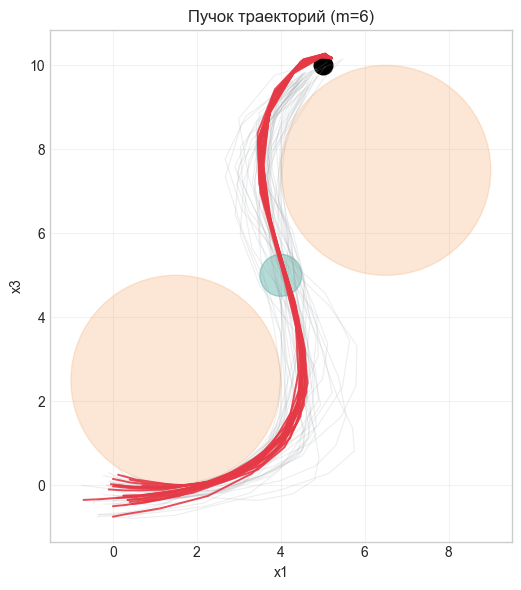

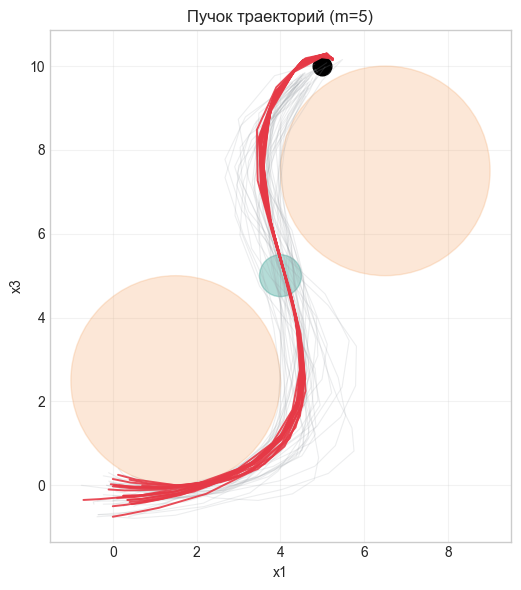

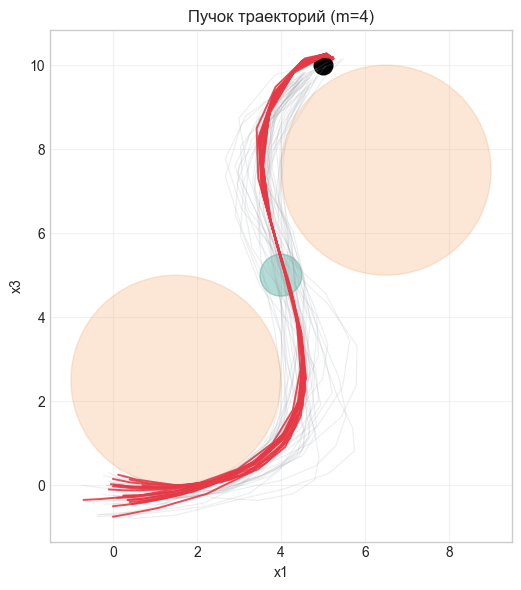

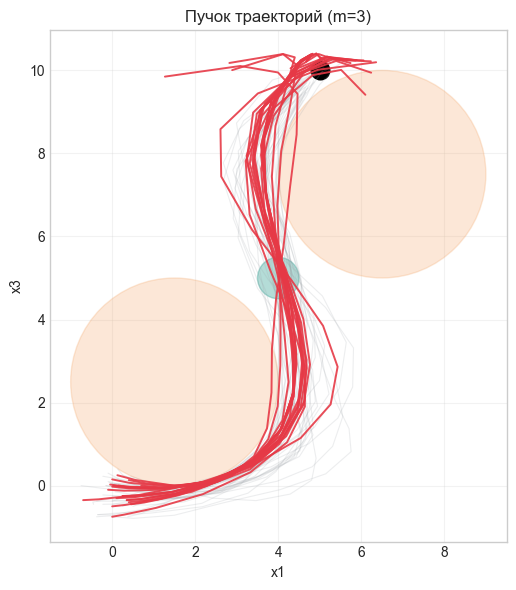

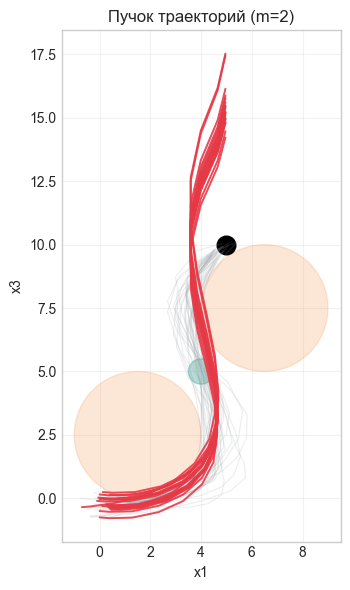

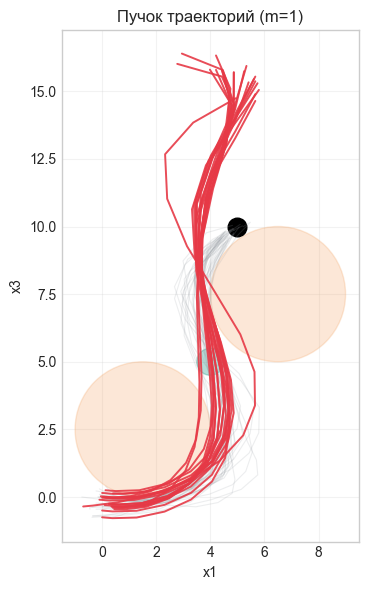

In [17]:
# Visualization: one figure per controller.
for m in FEATURE_DIMS:
    fig, ax = plt.subplots(figsize=(7, 6))

    # training bundle trajectories
    for tid in train_ids[:40]:
        X = selected[int(tid)]["X"]
        ax.plot(X[:, 0], X[:, 2], color="#9AA0A6", alpha=0.18, linewidth=0.8)

    # synthesized trajectories for this controller
    for r in controller_eval[m]["results"][:20]:
        S = r["states"]
        ax.plot(S[:, 0], S[:, 2], color="#E63946", alpha=0.9, linewidth=1.4)

    # obstacles and window
    for cyl in cfg.cylinders:
        ax.add_patch(plt.Circle((cyl.x, cyl.z), cyl.radius, color="#F4A261", alpha=0.25))
    for wnd in cfg.windows:
        ax.add_patch(plt.Circle((wnd.x, wnd.z), wnd.radius, color="#2A9D8F", alpha=0.35))

    # terminal point
    ax.scatter(
        [cfg.terminal_state[0]],
        [cfg.terminal_state[2]],
        marker="o",
        s=180,
        color="black",
        label="terminal",
    )

    ax.set_title(f"Пучок траекторий (m={m})")
    ax.set_xlabel("x1")
    ax.set_ylabel("x3")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

## Сравнение управления пучком траекторий с программным управлением

Beam controller (m): 6
Initial states used: 50
Synthesized control J_avg / J_max: 5.955141 6.783045
Program control     J_avg / J_max: 8.235726 11.601746


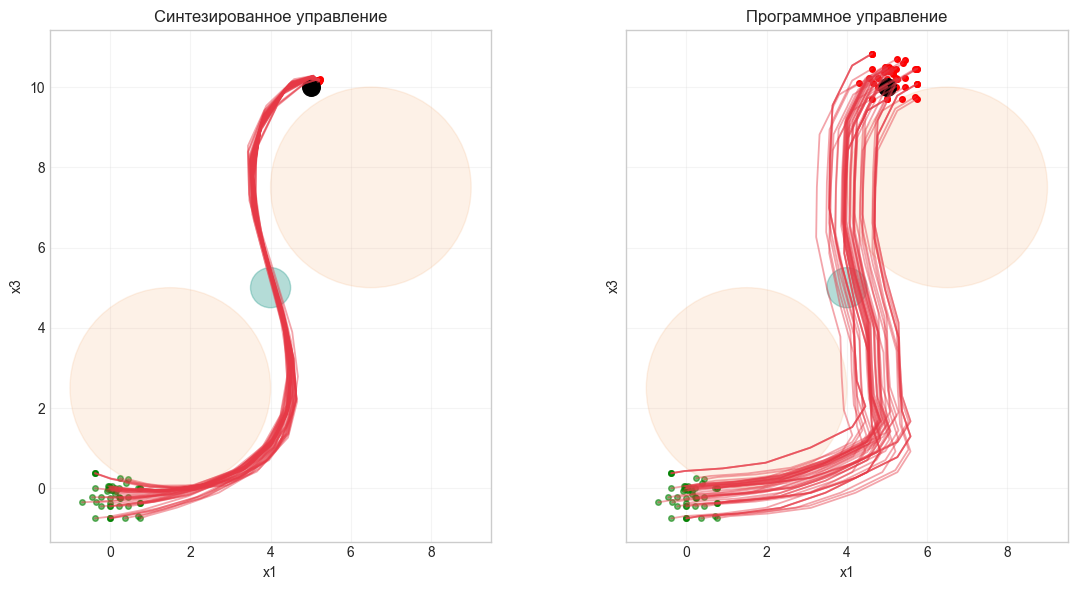

In [27]:
BEAM_LIMIT = 50
BEST_M_LOCAL = int(summary_df.loc[summary_df['j_avg'].idxmin(), 'm_features'])
controller_local = controllers[BEST_M_LOCAL]

# Beam of initial states.
bundle_initial_ids_8 = [int(tid) for tid in selected_ids[:BEAM_LIMIT]]
bundle_initial_states_8 = [np.asarray(selected[tid]['X'][0], dtype=float) for tid in bundle_initial_ids_8]

# Program control from best trajectory (analogue of db.get_best_program_control()).
best_tid_program = int(score_table.iloc[0]['trajectory_id'])
best_u_program = np.asarray(bundle[int(best_tid_program)]['U'], dtype=float)

results_synth = []
results_prog = []
j_synth = []
j_prog = []

for x0 in bundle_initial_states_8:
    # 1) Synthesized feedback control (beam controller).
    curr_x = x0.copy()
    traj_synth = [curr_x.copy()]
    controls_synth = []
    for step in range(1, N_STEPS + 1):
        u = controller_local.predict(curr_x, step)
        controls_synth.append(u.copy())
        curr_x = rollout(curr_x, np.asarray([u], dtype=float), cfg.dt)[-1]
        traj_synth.append(curr_x.copy())
    controls_synth = np.asarray(controls_synth, dtype=float)
    traj_synth = np.asarray(traj_synth, dtype=float)
    results_synth.append(traj_synth)
    j_synth.append(float(bolza_cost(x0, controls_synth, cfg)))

    # 2) Program control (open loop, no feedback): same best_u_program for each initial state.
    curr_x = x0.copy()
    traj_prog = [curr_x.copy()]
    controls_prog = []
    for step in range(1, N_STEPS + 1):
        idx = min(step - 1, len(best_u_program) - 1)
        u = np.asarray(best_u_program[idx], dtype=float)
        controls_prog.append(u.copy())
        curr_x = rollout(curr_x, np.asarray([u], dtype=float), cfg.dt)[-1]
        traj_prog.append(curr_x.copy())
    controls_prog = np.asarray(controls_prog, dtype=float)
    traj_prog = np.asarray(traj_prog, dtype=float)
    results_prog.append(traj_prog)
    j_prog.append(float(bolza_cost(x0, controls_prog, cfg)))

j_avg_synth = float(np.mean(j_synth))
j_max_synth = float(np.max(j_synth))
j_avg_prog = float(np.mean(j_prog))
j_max_prog = float(np.max(j_prog))

print(f'Beam controller (m): {BEST_M_LOCAL}')
print(f'Initial states used: {len(bundle_initial_states_8)}')
print('Synthesized control J_avg / J_max:', round(j_avg_synth, 6), round(j_max_synth, 6))
print('Program control     J_avg / J_max:', round(j_avg_prog, 6), round(j_max_prog, 6))

def plot_comparison_nb(ax, results, title, color):
    for x0 in bundle_initial_states_8:
        ax.scatter(x0[0], x0[2], marker='o', color='green', s=16, alpha=0.55)

    for cyl in cfg.cylinders:
        ax.add_patch(plt.Circle((cyl.x, cyl.z), cyl.radius, color='#F4A261', alpha=0.15))
    for wnd in cfg.windows:
        ax.add_patch(plt.Circle((wnd.x, wnd.z), wnd.radius, color="#2A9D8F", alpha=0.35))

    for traj in results:
        ax.plot(traj[:, 0], traj[:, 2], color=color, alpha=0.45, lw=1.3)
        ax.scatter(traj[-1, 0], traj[-1, 2], color='red', s=16)

    ax.scatter(cfg.terminal_state[0], cfg.terminal_state[2], marker='o', color='black', s=160)
    ax.set_title(title)
    ax.set_xlabel('x1')
    ax.set_ylabel('x3')
    ax.set_aspect('equal', adjustable='box')
    ax.grid(alpha=0.2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)
plot_comparison_nb(ax1, results_synth, 'Синтезированное управление', "#E63946")
plot_comparison_nb(ax2, results_prog, 'Программное управление', "#E63946")
plt.tight_layout()
plt.show()

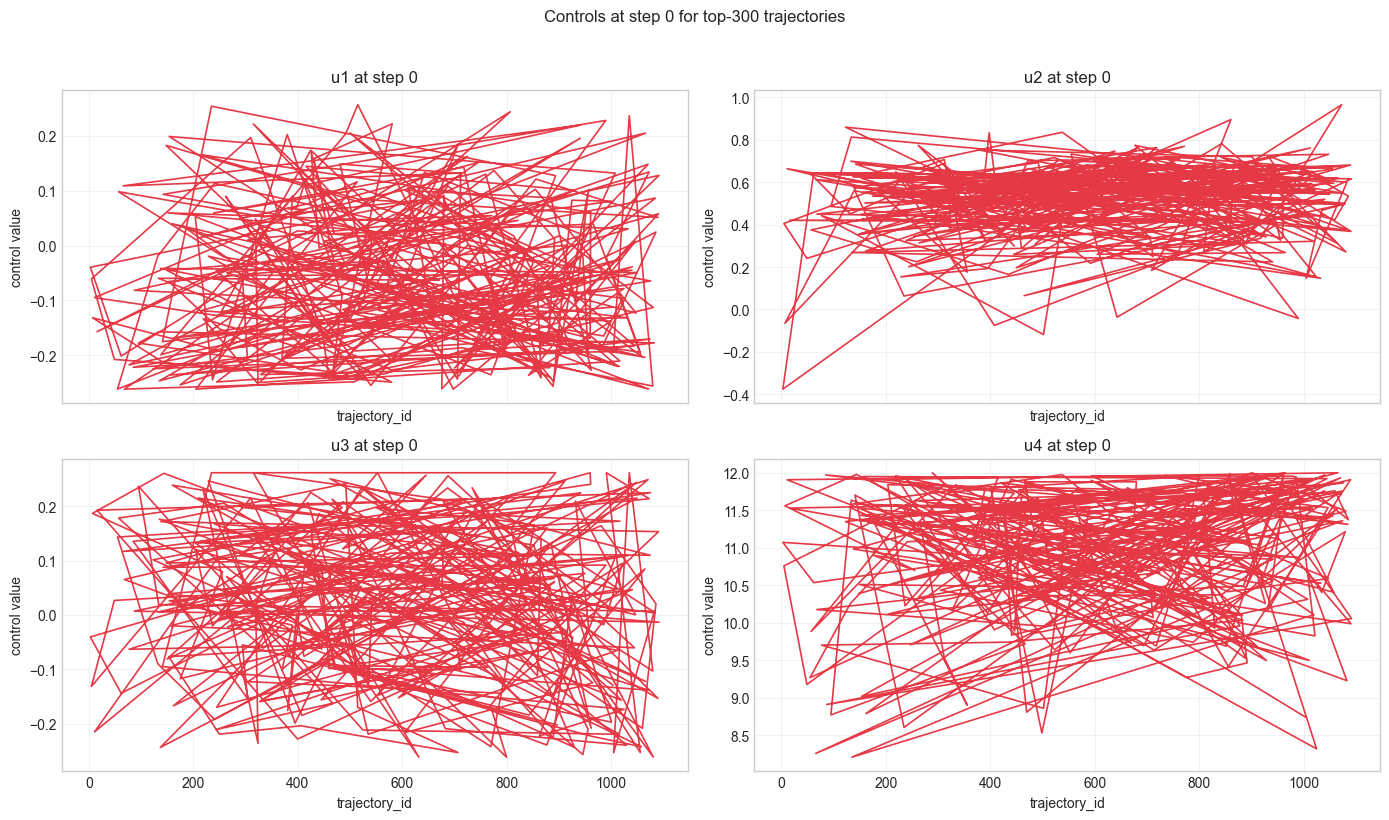

In [26]:
TOP_N = 300

# Берем TOP_N лучших траекторий по score.
top_df = score_table.nsmallest(TOP_N, 'score').copy()
trajectory_ids = top_df['trajectory_id'].astype(int).tolist()

# U(0) для каждой траектории: ожидаем 4 управления.
u0 = np.asarray([np.asarray(bundle[tid]['U'], dtype=float)[0] for tid in trajectory_ids], dtype=float)

if u0.shape[1] != 4:
    raise ValueError(f'Ожидалось 4 управления, получено: {u0.shape[1]}')

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
axes = axes.ravel()
control_labels = ['u1', 'u2', 'u3', 'u4']

x = np.asarray(trajectory_ids, dtype=int)
for i, ax in enumerate(axes):
    ax.plot(x, u0[:, i], linewidth=1.2, color='#E63946')
    ax.set_title(f'{control_labels[i]} at step 0')
    ax.set_xlabel('trajectory_id')
    ax.set_ylabel('control value')
    ax.grid(alpha=0.25)

plt.suptitle(f'Controls at step 0 for top-{len(trajectory_ids)} trajectories', y=1.02)
plt.tight_layout()
plt.show()